# Predicting Employee Burnout

## Modeling Objective

The goal of this notebook is to build machine learning models that predict employee burnout based on AI usage patterns, workplace characteristics, and employee attitudes.

### Target Variable

- `burnout_score`

### Models

- Linear Regression
- Random Forest Regressor
- Linear Regression (AI Features Only)
- Linear Regression (Without Job Satisfaction)

The purpose is not only to build accurate models, but also to understand which variables contribute most strongly to burnout.

# 1. Import Libraries

In [2]:
# Import data analysis, preprocessing, modeling, and evaluation libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

# 2. Load Cleaned Dataset



In [3]:
# Load cleaned burnout dataset

df = pd.read_csv(
    "../data/processed/ai_worker_burnout_cleaned.csv"
)

df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [4]:
# Display dataset dimensions

df.shape

(1500, 21)

In [5]:
# Review available variables

df.columns.tolist()

['employee_id',
 'job_role',
 'years_experience',
 'education_level',
 'country',
 'industry',
 'company_size',
 'remote_work_type',
 'team_size',
 'salary_usd_k',
 'primary_ai_tool',
 'ai_tools_used_per_day',
 'hours_with_ai_assistance_daily',
 'ai_replaces_my_tasks_pct',
 'ai_adoption_stage',
 'weekly_ai_upskilling_hrs',
 'productivity_score',
 'burnout_score',
 'job_satisfaction_1_5',
 'fear_of_ai_replacement',
 'attrition_risk']

# 3. Feature Selection

The target variable is `burnout_score`.

Predictors include demographic information, workplace characteristics, AI adoption variables, productivity measures, and employee attitudes toward AI.

In [6]:
# Define target variable and predictor set

target = "burnout_score"

features = [
    "job_role",
    "years_experience",
    "education_level",
    "country",
    "industry",
    "company_size",
    "remote_work_type",
    "salary_usd_k",
    "primary_ai_tool",
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "ai_adoption_stage",
    "weekly_ai_upskilling_hrs",
    "productivity_score",
    "job_satisfaction_1_5",
    "fear_of_ai_replacement"
]

X = df[features]
y = df[target]

In [7]:
# Separate numerical and categorical predictors

numeric_features = [
    "years_experience",
    "salary_usd_k",
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "weekly_ai_upskilling_hrs",
    "productivity_score",
    "job_satisfaction_1_5"
]

categorical_features = [
    "job_role",
    "education_level",
    "country",
    "industry",
    "company_size",
    "remote_work_type",
    "primary_ai_tool",
    "ai_adoption_stage",
    "fear_of_ai_replacement"
]

# 4. Train-Test Split

The dataset is divided into training and test sets.

The models learn patterns from the training data and are evaluated on unseen observations in the test set.

In [8]:
# Split dataset into training and test subsets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1200, 17)
(300, 17)


# 5. Data Preprocessing

Categorical variables cannot be used directly by most machine learning algorithms.

Therefore, one-hot encoding is applied to categorical features, while numerical variables are passed through unchanged.

In [9]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# 6. Model Evaluation Function

To compare models consistently, a reusable evaluation function is created.

Metrics:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Explained Variance)

In [10]:
# Create helper function for model evaluation

def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "mae": round(mae, 2),
        "rmse": round(rmse, 2),
        "r2": round(r2, 3)
    }

# 7. Baseline Model: Linear Regression

Linear Regression serves as a simple baseline model.

It assumes mostly linear relationships between burnout and the predictor variables.

In [11]:
# Train and evaluate Linear Regression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_results = evaluate_model(
    y_test,
    y_pred_linear,
    "Linear Regression"
)

linear_results

{'model': 'Linear Regression', 'mae': 5.42, 'rmse': 6.67, 'r2': 0.655}

# 8. Random Forest Model

Random Forest is a more flexible algorithm that can capture non-linear relationships and interactions between variables.

In [12]:
# Train and evaluate Random Forest Regressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                max_depth=8
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_results = evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)

rf_results

{'model': 'Random Forest', 'mae': 5.69, 'rmse': 7.03, 'r2': 0.617}

In [13]:
# Compare model performance

results = pd.DataFrame(
    [
        linear_results,
        rf_results
    ]
)

results

,model,mae,rmse,r2
0,Linear Regression,5.42,6.67,0.655
1,Random Forest,5.69,7.03,0.617


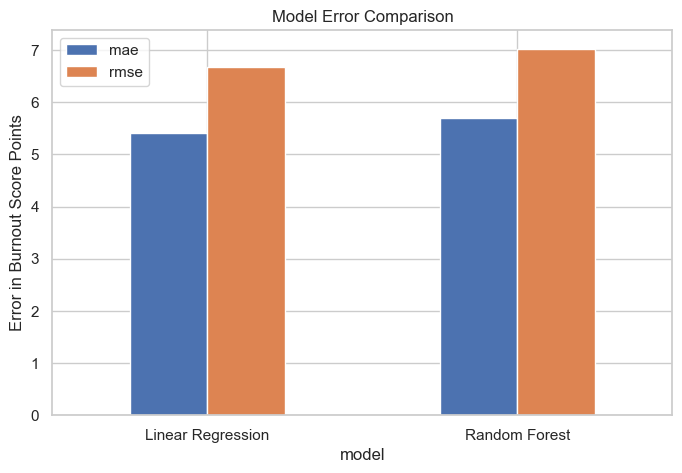

In [14]:
# Visualize model error metrics

results.set_index("model")[["mae", "rmse"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Error Comparison")
plt.ylabel("Error in Burnout Score Points")
plt.xticks(rotation=0)

plt.show()

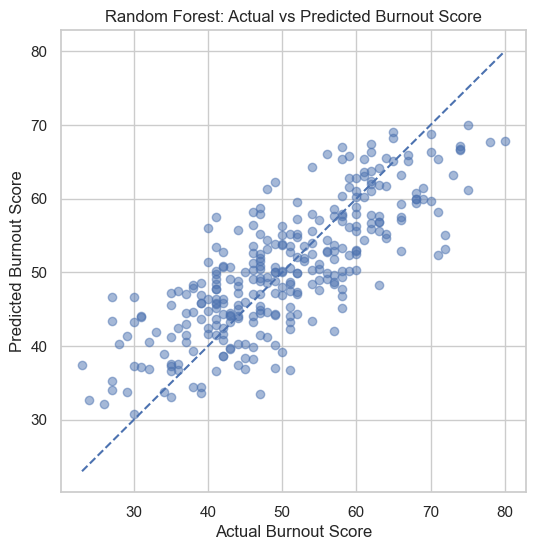

In [15]:
# Compare actual and predicted burnout scores for Random Forest

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Burnout Score")
plt.ylabel("Predicted Burnout Score")
plt.title("Random Forest: Actual vs Predicted Burnout Score")

plt.show()

### Model Comparison Interpretation

The Random Forest model was tested because it can model complex relationships.

Linear Regression performs slightly better, this suggests that the relationships in the dataset are largely linear and do not require highly flexible algorithms.

# 9. AI-Only Model

This model uses only AI-related variables.

The purpose is to test how much burnout can be explained by AI adoption, AI usage intensity, and AI replacement concerns alone.

In [16]:
# Define AI-only feature set

ai_features = [
    "primary_ai_tool",
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "ai_adoption_stage",
    "weekly_ai_upskilling_hrs",
    "fear_of_ai_replacement"
]

X_ai = df[ai_features]
y = df["burnout_score"]

In [17]:
# Define AI-only numerical and categorical variables

ai_numeric_features = [
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "weekly_ai_upskilling_hrs"
]

ai_categorical_features = [
    "primary_ai_tool",
    "ai_adoption_stage",
    "fear_of_ai_replacement"
]

In [18]:
# Split AI-only dataset

X_ai_train, X_ai_test, y_ai_train, y_ai_test = train_test_split(
    X_ai,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
# Create AI-only preprocessing pipeline

ai_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            ai_categorical_features
        )
    ],
    remainder="passthrough"
)

In [20]:
# Train AI-only Linear Regression model

ai_linear_model = Pipeline(
    steps=[
        ("preprocessor", ai_preprocessor),
        ("model", LinearRegression())
    ]
)

ai_linear_model.fit(X_ai_train, y_ai_train)

y_pred_ai_linear = ai_linear_model.predict(X_ai_test)

In [21]:
# Evaluate AI-only model

ai_linear_results = evaluate_model(
    y_ai_test,
    y_pred_ai_linear,
    "Linear Regression - AI Features Only"
)

ai_linear_results

{'model': 'Linear Regression - AI Features Only',
 'mae': 6.16,
 'rmse': 7.53,
 'r2': 0.56}

In [22]:
# Compare all current models

results_extended = pd.DataFrame(
    [
        linear_results,
        rf_results,
        ai_linear_results
    ]
)

results_extended

,model,mae,rmse,r2
0,Linear Regression,5.42,6.67,0.655
1,Random Forest,5.69,7.03,0.617
2,Linear Regression - AI Features Only,6.16,7.53,0.560


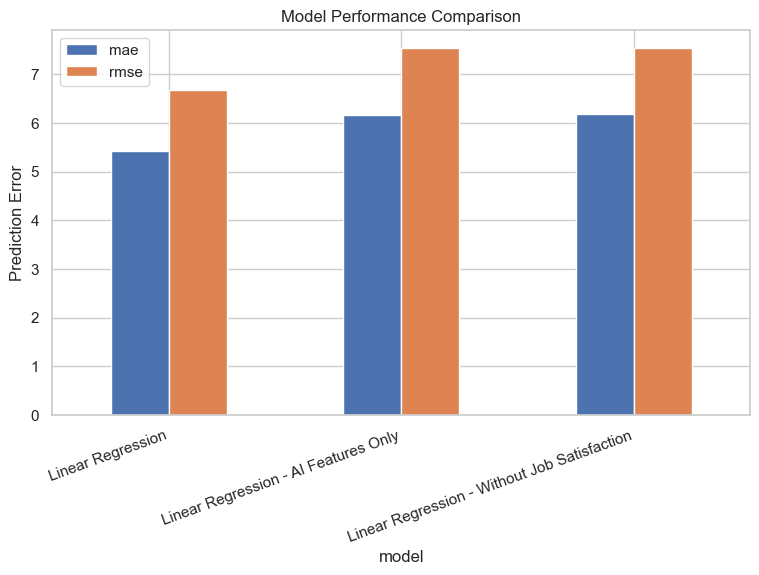

In [41]:
# Visualize model comparison

results_extended.set_index("model")[["mae", "rmse"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Prediction Error")
plt.xticks(rotation=20, ha="right")

plt.show()

### AI-Only Model Interpretation

The AI-only model performs close to the full model, this suggests that AI-related variables contain substantial information about employee burnout.

# 10. Feature Importance Analysis

Linear Regression coefficients are used to identify which variables have the strongest positive and negative association with burnout.

In [24]:
# Extract transformed feature names

feature_names = (
    linear_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_names[:10]

array(['cat__job_role_AI Ethics Officer', 'cat__job_role_AI Researcher',
       'cat__job_role_Backend Engineer', 'cat__job_role_Cloud Architect',
       'cat__job_role_Data Analyst', 'cat__job_role_Data Scientist',
       'cat__job_role_DevOps Engineer', 'cat__job_role_Frontend Engineer',
       'cat__job_role_ML Engineer', 'cat__job_role_Product Manager'],
      dtype=object)

In [25]:
# Extract regression coefficients

coefficients = (
    linear_model.named_steps["model"]
    .coef_
)

In [26]:
# Create coefficient table

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df.head()

,feature,coefficient
0,cat__job_role_AI Ethics Officer,-1.267857
1,cat__job_role_AI Researcher,-0.279757
2,cat__job_role_Backend Engineer,0.679538
3,cat__job_role_Cloud Architect,-0.264392
4,cat__job_role_Data Analyst,0.846397


In [27]:
# Largest positive coefficients

coef_df.sort_values(
    "coefficient",
    ascending=False
).head(15)

,feature,coefficient
63,remainder__hours_with_ai_assistance_daily,1.469360
47,cat__primary_ai_tool_Cursor,1.039853
5,cat__job_role_Data Scientist,0.848719
4,cat__job_role_Data Analyst,0.846397
24,cat__country_Singapore,0.760392
31,cat__industry_EdTech,0.726860
16,cat__education_level_Self-taught,0.724826
18,cat__country_Brazil,0.703875
2,cat__job_role_Backend Engineer,0.679538
30,cat__industry_E-commerce,0.560746


In [28]:
# Largest negative coefficients

coef_df.sort_values(
    "coefficient",
    ascending=True
).head(15)

,feature,coefficient
67,remainder__job_satisfaction_1_5,-7.001570
0,cat__job_role_AI Ethics Officer,-1.267857
26,cat__country_USA,-1.246299
28,cat__industry_Consulting,-0.973320
27,cat__industry_Automotive,-0.909070
22,cat__country_India,-0.842873
49,cat__primary_ai_tool_GitHub Copilot,-0.711154
10,cat__job_role_Prompt Engineer,-0.650367
25,cat__country_UK,-0.583378
29,cat__industry_Cybersecurity,-0.481492


In [29]:
# Identify strongest overall coefficients

coef_df["abs_coef"] = coef_df["coefficient"].abs()

top_features = (
    coef_df
    .sort_values("abs_coef", ascending=False)
    .head(10)
)

top_features

,feature,coefficient,abs_coef
67,remainder__job_satisfaction_1_5,-7.001570,7.001570
63,remainder__hours_with_ai_assistance_daily,1.469360,1.469360
0,cat__job_role_AI Ethics Officer,-1.267857,1.267857
26,cat__country_USA,-1.246299,1.246299
47,cat__primary_ai_tool_Cursor,1.039853,1.039853
28,cat__industry_Consulting,-0.973320,0.973320
27,cat__industry_Automotive,-0.909070,0.909070
5,cat__job_role_Data Scientist,0.848719,0.848719
4,cat__job_role_Data Analyst,0.846397,0.846397
22,cat__country_India,-0.842873,0.842873


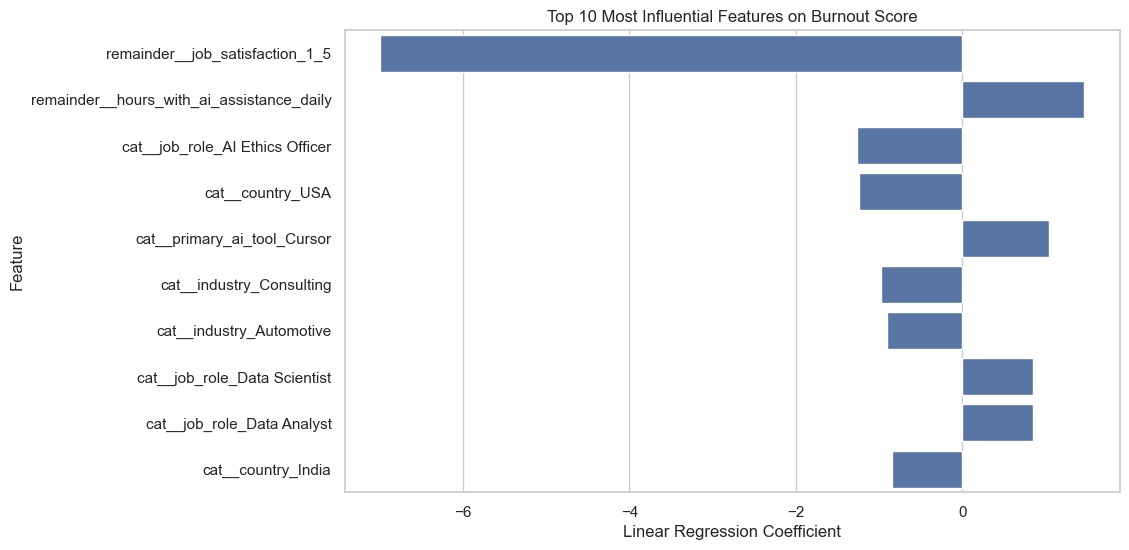

In [30]:
# Visualize most influential features

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="coefficient",
    y="feature"
)

plt.title("Top 10 Most Influential Features on Burnout Score")
plt.xlabel("Linear Regression Coefficient")
plt.ylabel("Feature")

plt.show()

### Feature Importance Interpretation

The coefficient analysis helps identify which variables contribute most strongly to burnout predictions.

Positive coefficients increase predicted burnout, while negative coefficients decrease predicted burnout.

# 11. Sensitivity Analysis

Job satisfaction is expected to be strongly related to burnout.

To evaluate its influence, an additional model is trained without job satisfaction.

In [31]:
# Remove job satisfaction from feature set

features_no_satisfaction = [
    col for col in features
    if col != "job_satisfaction_1_5"
]

X_ns = df[features_no_satisfaction]
y = df["burnout_score"]

In [32]:
# Define numerical and categorical features without satisfaction

numeric_ns_features = [
    "years_experience",
    "salary_usd_k",
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "weekly_ai_upskilling_hrs",
    "productivity_score"
]

categorical_ns_features = [
    "job_role",
    "education_level",
    "country",
    "industry",
    "company_size",
    "remote_work_type",
    "primary_ai_tool",
    "ai_adoption_stage",
    "fear_of_ai_replacement"
]

In [33]:
# Split data

X_ns_train, X_ns_test, y_ns_train, y_ns_test = train_test_split(
    X_ns,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
# Create preprocessing pipeline

ns_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_ns_features
        )
    ],
    remainder="passthrough"
)

In [35]:
# Train model without job satisfaction

ns_linear_model = Pipeline(
    steps=[
        ("preprocessor", ns_preprocessor),
        ("model", LinearRegression())
    ]
)

ns_linear_model.fit(X_ns_train, y_ns_train)

y_pred_ns_linear = ns_linear_model.predict(X_ns_test)

In [36]:
# Evaluate model without job satisfaction

ns_linear_results = evaluate_model(
    y_ns_test,
    y_pred_ns_linear,
    "Linear Regression - Without Job Satisfaction"
)

ns_linear_results

{'model': 'Linear Regression - Without Job Satisfaction',
 'mae': 6.19,
 'rmse': 7.53,
 'r2': 0.56}

In [37]:
# Compare selected model variants

results_extended = pd.DataFrame(
    [
        linear_results,
        ai_linear_results,
        ns_linear_results
    ]
)

results_extended

,model,mae,rmse,r2
0,Linear Regression,5.42,6.67,0.655
1,Linear Regression - AI Features Only,6.16,7.53,0.560
2,Linear Regression - Without Job Satisfaction,6.19,7.53,0.560


In [38]:
# Compare R² values directly

print(r2_score(y_ai_test, y_pred_ai_linear))
print(r2_score(y_ns_test, y_pred_ns_linear))

0.5595794133176892
0.5603704383744266


### Sensitivity Analysis Interpretation

Comparing the AI-only model and the model without job satisfaction helps determine how much predictive information comes from workplace satisfaction versus AI-related variables.

If the AI-only model remains competitive, AI-related variables represent an important source of information about burnout.

# 12. Conclusion

Key findings:

- Linear Regression provides strong predictive performance and serves as a robust baseline.
- Random Forest does not substantially outperform Linear Regression.
- AI-related variables alone explain a large proportion of burnout variation.
- Job satisfaction contributes important information, but AI-related predictors remain highly informative.
- Feature coefficient analysis identifies the strongest positive and negative burnout predictors.

Overall, burnout appears to be influenced by both traditional workplace factors and AI-related work experiences. The modeling results support the conclusion that AI adoption variables contain meaningful predictive information for employee wellbeing.